<a href="https://colab.research.google.com/github/MishelleMurcia26/Analitica-de-Negocios-/blob/main/Parcial_1_Mishelle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Caso de estudio**

En este documento se desarrolla y analiza la aplicación de modelos de clasificación para la identificación de pacientes con diabetes en una entidad del sector salud, utilizando variables relacionadas con su condición médica. Para ello se emplea la base de datos Pima Indians Diabetes Database, la cual contiene información clínica de pacientes que permite determinar la presencia o ausencia de diabetes.

De acuerdo con lo anterior, se implementan y comparan tres modelos de análisis: Naive Bayes, Árboles de Decisión y Clustering K-Means, evaluando su desempeño mediante la matriz de confusión y métricas de clasificación. Las variables utilizadas incluyen:

Pregnancies: Número de embarazos que ha tenido la paciente.

Glucose: Nivel de concentración de glucosa en sangre.

Blood pressure: Presión arterial diastólica medida en mm Hg.

Skin thickness: Espesor del pliegue cutáneo del tríceps, utilizado como indicador de grasa corporal.

Insulin: Nivel de insulina en sangre.

BMI: Índice de masa corporal, que relaciona peso y estatura.

Diabetes pedigree function: Función que estima la probabilidad de diabetes basada en antecedentes familiares.

Age: Edad del paciente.

Outcome: Variable objetivo que indica si el paciente presenta diabetes (1) o no (0).

0.Se procede con la carga de las librerias del trabajo

In [ ]:
import numpy as np
import pandas as pd

#NAIVE BAYES
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

#ARBOL DE DECISIONES
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

#Clustering K-Means
import seaborn as sns
from sklearn.cluster import KMeans

#**Modelo Naive Bayes**

1.Se cargan los datos de trabajo del Naive Bayes

In [ ]:
nxl="/content/diabetes.csv"
XDB=pd.read_csv(nxl)

#Seleccionamos variables de trabajo
XD=XDB[["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]]
XD.head(10)
yd=XDB[["Outcome"]] #Esta es la variable de decision
yd.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


2.Implementamos modelo Naive Bayes

In [ ]:
mnb=GaussianNB()
mnb.fit(XD,yd)

#Mostrar las medias de las variables
u=mnb.theta_
sigma=mnb.var_; sigma=np.sqrt(sigma) #Desviacion estandar
print("Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age")
print(u)
print("La desviacion estandar es: ")
print(sigma)

Pregnancies Glucose BloodPressure SkinThickness Insulin BMI DiabetesPedigreeFunction Age
[[  3.298      109.98        68.184       19.664       68.792
   30.3042       0.429734    31.19      ]
 [  4.86567164 141.25746269  70.82462687  22.1641791  100.3358209
   35.14253731   0.5505      37.06716418]]
La desviacion estandar es: 
[[  3.01416809  26.11504573  18.04500366  14.87505016  98.76637459
    7.68216217   0.29880826  11.65598187]
 [  3.73425437  31.87997773  21.45167782  17.64669641 138.43013459
    7.24940518   0.37167699  10.94777197]]


**Analisis de resultados**:
De acuerdo con los resultados obtenidos por el modelo, se observa que la categoria de pacientes con posibilidad de diabetes posee glucosas mayores que la categoria de pacietnes sin posibilidad de diabetes, lo que nos indica que los pacientes catalogados con posibilidad de diabetes podrian llegar a tener mas niveles de glucosa, y como se observa mayor numero de indice de masa corporal.Podemos decir que la parte de antecedentes del arbol genealogicos muestra como los catalogados con posibilidad de diabetes son mas altos que los de no riesgo por su alto indice de de probabilidad de padeserlo, y para concluir las personas con posibilidad de diabetes tienden a tener a ser mayores al padecer esta enfermedad

3.Se procede con la evaluacion del modelo Naive Bayes. Utilizando la matriz de confusion

In [ ]:
ydp=mnb.predict(XD)
cm=confusion_matrix(yd,ydp)
print(cm)

#Se determina las metricas de la matriz de confusion
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1];TDatos=len(XDB)

#1. Exactitud: Funcionamiento general del modelo
EX=(VP+VN)/TDatos
print("Exactitud: ",EX)

#2. Tasa Error: %Fallos del modelo
TEr=(FP+FN)/TDatos
print("Tasa Error: ",TEr)

#3. Sensibilidad: Como se comporto con respecto a los positivos solamente
Se=VP/(VP+FN)
print("Sensibilidad: ",Se)

#4. Especificidad: Como se comporta pronosticando negativos
Es=VN/(VN+FP)
print("Especificidad: ",Es)

#5. Precision: Es una version de como se comporta el modelo frente a los positivos solamente
Pr=VP/(VP+FP)
print("Precision: ",Pr)

#6. Prediccion negativa: Como funciona el modelo pronosticando acciones extrañas
PrN=VN/(VN+FN)
print("Prediccion Negativa: ",PrN)

[[421  79]
 [103 165]]
Exactitud:  0.7630208333333334
Tasa Error:  0.23697916666666666
Sensibilidad:  0.6156716417910447
Especificidad:  0.842
Precision:  0.6762295081967213
Prediccion Negativa:  0.8034351145038168


**Analisis de resultados **:De acuerdo con los resultados obtenidos por el modelo, se observa que el modelo alcanzó una exactitud del 76.3%, lo que indica un buen comportamiento en la clasificación de pacientes con y sin diabetes. Esto significa que el modelo logra clasificar correctamente a la mayoría de los pacientes presentes en el dataset

Se destaca una tasa de error del 23.6%, lo que muestra que aún existen algunos casos donde el modelo no logra identificar correctamente la presencia o ausencia de la enfermedad. Sin embargo, el modelo presenta un buen desempeño al identificar pacientes sin diabetes, lo cual se refleja en una especificidad del 84.2%, indicando que el modelo es bastante efectivo al reconocer correctamente a los pacientes que no presentan la enfermedad.

Por otro lado, la sensibilidad del modelo es del 61.5%, lo que indica que el modelo tiene más dificultad para identificar correctamente a los pacientes que sí presentan diabetes. Esto afecta directamente la capacidad del modelo para detectar todos los casos positivos. Finalmente, la precisión del 67.6% muestra que una parte de los pacientes que el modelo clasifica como diabéticos realmente presentan la enfermedad, mientras que la predicción negativa del 80.3% indica que la mayoría de los pacientes clasificados como no diabéticos efectivamente no padecen la enfermedad.

4.Evaluamos un paciente. Pregnancies=2, Glucose=85,	BloodPressure=65,	SkinThickness=29,	Insulin=94,	BMI=39.6,	DiabetesPedigreeFunction=0.93, Age=27

In [ ]:
XP=[2,85,65,29,94,39.6,0.93,27]
ydc=mnb.predict([XP])
print("El diagnostico del paciente es: ",ydc)

if ydc==1:
  print("El paciente presenta diabetes")
else:
  print("el paciente no presenta diabetes ")

El diagnostico del paciente es:  [0]
el paciente no presenta diabetes 


#**Modelo arbol de decision**

1.Se cargan los datos de trabajo Arbol de decisiones

In [ ]:
nxa="/content/diabetes.csv"
arbol=pd.read_csv(nxa)
arbol.head(100)

#Seleccionamos variables de trabajo

MD=arbol.iloc[:,[0,1,2,3,4,5,6,7]]
nd=arbol.iloc[:,8]
display(XDB)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


2.Se procede con la implementacion del modelo del arbol

In [ ]:
mar=DecisionTreeClassifier(criterion="gini",max_depth=4)
mar.fit(MD,nd)

YDP=mar.predict(MD)
YDP

#Se construye la matrix de confusion
cm=confusion_matrix(nd,YDP)
display(cm)
VN=cm[0,0]
FP=cm[0,1]
FN=cm[1,0]
VP=cm[1,1]

#Metricas de desempeno

#Exactitud: Comportamiento general
EX=(VP+VN)/len(MD)
print("Exactitud: ",EX)

#2. Tasa Error: %Fallos del modelo
TEr=(FP+FN)/len(MD)
print("Tasa Error: ",TEr)

#3. Sensibilidad: Como se comporta pronosticando diabetes
Se=VP/(VP+FN)
print("Sensibilidad: ",Se)

#4. Especificidad: Como se comporta pronosticando no diabetes
Es=VN/(VN+FP)
print("Especificidad: ",Es)

#5. Precision: Es una version de como se comporta el modelo frente a los positivos solamente
Pr=VP/(VP+FP)
print("Precision: ",Pr)

#6. Prediccion negativa: Como funciona el modelo pronosticando no diabeticos
PrN=VN/(VN+FN)
print("Prediccion Negativa: ",PrN)

array([[459,  41],
       [119, 149]])

Exactitud:  0.7916666666666666
Tasa Error:  0.20833333333333334
Sensibilidad:  0.5559701492537313
Especificidad:  0.918
Precision:  0.7842105263157895
Prediccion Negativa:  0.7941176470588235


3.Despliegue del arbol de decision

In [ ]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data

vs=["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"] #Titulos del arbol
dot_data=export_graphviz(mar,feature_names=vs)
graph=graph_from_dot_data(dot_data)
graph.write_pdf('Arbol.pdf')

True

Analisis de resultados de la base de datos se puede observar un total de 500 paciente que poseen la categoria de no riesgo de diabetes, mientras que para la categoria de riesgo cuenta con un total de 268 pacientes con riesgo de diabetes. De los 500 datos el modelo pronostico correctamente un total de 457 datos. De los 268 pacientes con riesgo de diabetes el modelo pronostico correctamente un total de 118. El modelo logra identificar en un 54% los pacientes sin riesgo de diabetes(268/500), mientras que el modelo logro identificar en un 44% los pacientes con riesgo de diabetes(118/268).

Con respecto a las metricas podemos observar que el modelo logro una exactitud, 79%, lo que indica el buen comportamiento general del modelo frente a la clasificacion de pacientes en las dos categorias de riesgo de diabetes. Se destacan la especificidad la cual logro un valor de 91%,indicando que el modelo es bastante efectivo al reconocer correctamente a los pacientes que no presentan la enfermedad. Ademas se puede observar que tanto la precision como la prediccion negativa cuentan con porcentaje de casi 80%.

De acuerdo con el arbol de decision se destacan cinco nodos puros (10/0), describamos uno en su totalidad el cual posee la siguiente regla de decision, si una persona cumple con esta SI Glucose<= 127.5 AND Age<= 28.5 AND BMI<=26.35 AND BMI<=9.65, tendra una posibilidad de aprobacion del 100%. Es importante destacar que los nodos puros poseen un gini=0 (El modelo diferencia muy bien los DIABETICOS)

A pesar de contar con la existencia de mas nodos puros, destacaremos los nodos extremos o las reglas del negocio entremas.Se destaca una regla que lograr un porcentaje de riesgo de diabetes del 98% y la cual posee la siguiente estructura: SI Glucose<= 127.5 AND Age<= 28.5 AND BMI<=45.4 AND BMI<=30.95.

4.Ahora con un paciente. Pregnancies=2, Glucose=85,	BloodPressure=65,	SkinThickness=29,	Insulin=94,	BMI=39.6,	DiabetesPedigreeFunction=0.93, Age=27

In [ ]:
AD=[2,85,65,29,94,39.6,0.93,27]

yde=mar.predict([AD])
if yde==1:
  print("El paciente presenta diabetes")
else:
  print("El paciente no presenta diabetes ")

El paciente no presenta diabetes 


#**Modelo Clustering K-Means**

1.Se cargan los datos de trabajo del modelo Clustering K-Means

<Axes: >

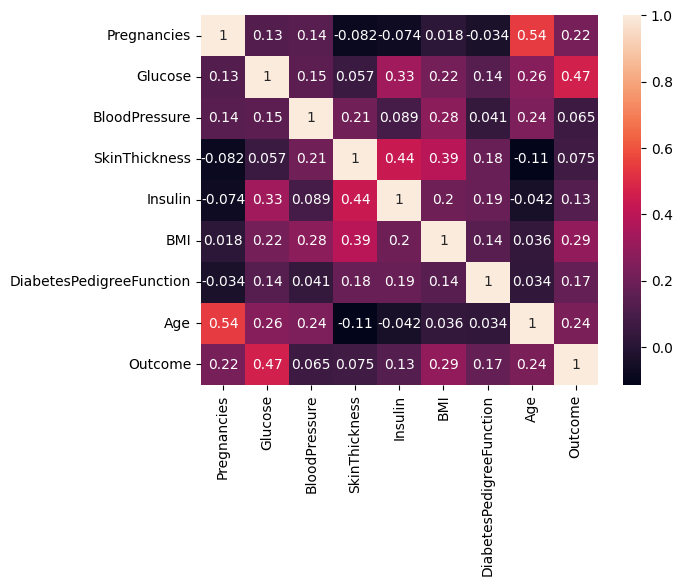

In [ ]:
nxc="/content/diabetes.csv"
XDC=pd.read_csv(nxl)

#Seleccionamos variables de trabajo

DD=XDC.iloc[:,[0,1,2,3,4,5,6,7]]
ld=XDC.iloc[:,8]

#Determinamos la correlacion entre las varibales
XDB2=XDC.iloc[:,[0,1,2,3,4,5,6,7,8]]
sns.heatmap(XDB2.corr(),annot=True)

2.Se procede con la implementacion del modelo KMeans

In [ ]:
from pandas.io.pytables import TableIterator
np.random.seed(42)
NC=5
mkm=KMeans(n_clusters=NC,random_state=42)
mkm.fit(DD)

#Obtenemos las caracteristicas de cada grupo
#Representa los perfiles de las perdonas mkm.cluster_centers_ que encontro el modelo
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=DD.columns)
display(Tabla)

#Para saber los porcentajes de posibles diabeticos o posibles no diabeticos por segmento, sucursal o perfil
ydp=mkm.labels_ #Esto me indica en que cluster queda clasificado cada dato
NDc=np.bincount(ydp)
print("El numero de datos por cluster es:  ", NDc)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4.250000,149.615385,74.038462,30.865385,291.480769,35.575000,0.558635,33.903846
1,4.403646,119.096354,67.372396,11.932292,0.562500,30.954167,0.422201,35.583333
2,2.638418,101.954802,68.841808,26.853107,77.841808,31.096610,0.469458,27.836158
3,3.111111,165.833333,73.444444,35.666667,548.833333,36.961111,0.660667,34.555556
4,3.781022,133.598540,71.861314,30.583942,162.452555,34.048175,0.556504,33.233577


El numero de datos por cluster es:   [ 52 384 177  18 137]


3.Porcentaje de Outcome

In [ ]:
df_for_clustering_analysis = XDC.copy()
df_for_clustering_analysis["Cluster"] = ydp
display(df_for_clustering_analysis)

# Determinar el nuemro de posibles diabeticos y posibles no diabeticos por cluster
NDia=df_for_clustering_analysis.groupby("Cluster").agg({"Outcome":lambda x: (x==1).sum()})
NNDia=df_for_clustering_analysis.groupby("Cluster").agg({"Outcome":lambda x: (x==0).sum()})
#Para que la decision sea en porcentaje
NDia2=NDia/(NDia+NNDia);NNDia2=NNDia/(NDia+NNDia)
df2=pd.DataFrame(np.column_stack((NDia2,NNDia2)),columns=["PosDia","PosNDia"])
display(df2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148,72,35,0,33.6,0.627,50,1,1
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,2
4,0,137,40,35,168,43.1,2.288,33,1,4
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,4
764,2,122,70,27,0,36.8,0.340,27,0,1
765,5,121,72,23,112,26.2,0.245,30,0,2
766,1,126,60,0,0,30.1,0.349,47,1,1


,PosDia,PosNDia
0,0.500000,0.500000
1,0.364583,0.635417
2,0.129944,0.870056
3,0.666667,0.333333
4,0.489051,0.510949


4.Que pasa si aparece una nueva persona? Pregnancies=2, Glucose=85,	BloodPressure=65,	SkinThickness=29,	Insulin=94,	BMI=39.6,	DiabetesPedigreeFunction=0.93, Age=27

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
Patricia=np.array([[2,85,65,29,94,39.6,0.93,27]])
ydp=mkm.predict(Patricia)  #Reshape= quitarle la estructura
NC1=ydp[0]   #Esto indica el cluster al que pertenece una persona
print("La persona pertenece al cluster: ", ydp)
print("El porcentaje de posibilidad de diabetes para patricia es :", NDia2.iloc[NC1])
print("El porcentaje de no posibilidad de diabetes para patricia es :", NNDia2.iloc[NC1])

La persona pertenece al cluster:  [2]
El porcentaje de posibilidad de diabetes para patricia es : Outcome    0.129944
Name: 2, dtype: float64
El porcentaje de no posibilidad de diabetes para patricia es : Outcome    0.870056
Name: 2, dtype: float64


5. Se procede con la grafica de los clusters utilizando las variables Glucose y Outcome

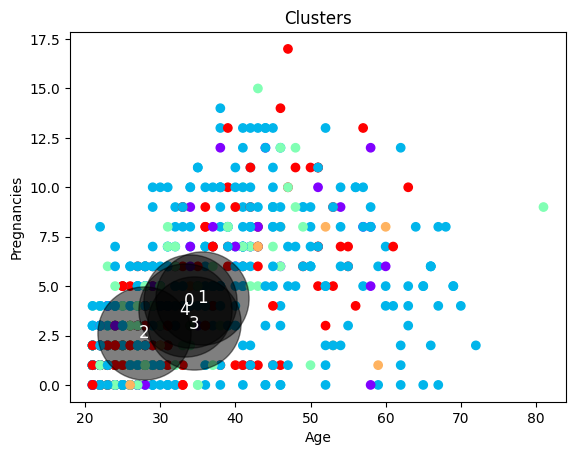

In [ ]:
centers=mkm.cluster_centers_  #Centroides, perfil; o segmento
Age=np.array(DD.iloc[:,7])
Preg=np.array(DD.iloc[:,0])
plt.figure()
plt.scatter(Age,Preg,c=mkm.labels_,cmap="rainbow")
plt.scatter(centers[:,7],centers[:,0],c="black",s=4500,alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Pregnancies")
plt.title("Clusters")

#Add numbers to the centers
for i,center in enumerate(centers):
  plt.text(center[7], center[0], str(i), color="white", fontsize=12, ha="center", va="center")
plt.show()


**Analisis de resultado**
En el heatmap se puede observar que la variable que presenta la mayor correlación es Age y Pregnancies, lo que indica que a medida que aumentan la edad de los pacientes, también aumenta la probabilidad de embarazo.

Otra correlación relevante es la que existe entre la variable de salida Outcome y DiabetesPedigreeFunction(0.47), lo que sugiere que entre mayores son los antecedentes genealogicos de diabetes mayor probabilidad de padecer la enfermedad. También se observa una relación entre BMI y SkinThickness(0.39), indicando que entre mayor es el indice de masa corporal, mayor es el grosor de la piel

De acuerdo con los segmentos o cluster arrojados por el modelo podemos observar que el cluster 0 y el cluster 3 son los que poseen la glucosa y el indice de masa corporal mas altos con 149.61 y 165.83 la glucosa; 35.6 y 36.9 el indice de masa corporal respectivamente. Los cluster 1 y 2 tienen el menor numero de antecedentes en la linea familiar con 0.42 y 0.46. Se destaca el primer cluster, el cual agrupa a las personas con menos presion sanguinea(67.37).

Se puede observar que el cluster 3 agrupa la posibilidad mas altas frente a la posibilidad de tener diabetes con un 66% de riesgo.Ademas se puede observar que el cluster 2 agrupa la posibilidad mas alta frente a la posibilidad de no tener diabetes con un 87%. Es importante mencionar que el cluster 2 tuvo los menores porcentaje de posibilidades de tener diabetes con un 13%, esto promovido por los menores indices de glucosa y menores antecedentes familiares de diabetes ademas de otros factores.

#**Analisis comparativo de los modelos**

Al comparar los tres modelos aplicados a la base de datos para identificar pacientes con diabetes, se puede observar que cada uno aporta información útil, pero con diferentes enfoques.

El modelo Naive Bayes presentó un desempeño aceptable, con una exactitud cercana al 76.3%, lo que indica que logra clasificar correctamente a la mayoría de los pacientes. Sin embargo su sensibilidad fue relativamente baja, lo que muestra que el modelo tiene algunas dificultades para identificar correctamente a todos los pacientes que realmente tienen diabetes.

Por su parte el modelo K-Means permitió agrupar a los pacientes en cinco clusters, identificando grupos con características similares en variables como Pregnancies,	Glucose,	BloodPressure,	SkinThickness,	Insulin,	BMI,DiabetesPedigreeFunction y Age. Esto ayuda a entender mejor cómo se comportan los diferentes perfiles de pacientes, pero al ser un modelo de agrupamiento y no de predicción directa su uso para diagnosticar diabetes es más limitado.

El Árbol de Decisión en cambio, mostró un mejor equilibrio entre resultados y facilidad de interpretación. Este modelo alcanzó una exactitud del 79.1%, además de una especificidad del 91.8%, lo que indica que identifica muy bien a los pacientes que no tienen diabetes. También presentó una precisión del 78.4%, mostrando que la mayoría de los pacientes clasificados como diabéticos realmente lo son. Además permite ver claramente las reglas de decisión, donde variables como Pregnancies,	Glucose,	BloodPressure,	SkinThickness,	Insulin,	BMI,DiabetesPedigreeFunction y Age influyen directamente en la clasificación.

Por esta razón, el Árbol de Decisión es el modelo más recomendable, ya que no solo tiene buenos resultados en las métricas, sino que también permite entender fácilmente cómo se toman las decisiones del modelo, algo muy importante cuando se trabaja con información del sector salud.
